In [2]:
from pathlib import Path

BASE_PATH = Path("../")
MD_PATH = "md-mlff/300k"

In [3]:
from pymatgen.io.vasp import Xdatcar, Incar
import json
import numpy as np

systems = {
    "01_hzzrs3": {"name": "HzZrS3"},
    "02_hzzrse3": {"name": "HzZrSe3"},
    "03_hzhfs3": {"name": "HzHfS3"},
    "04_hzhfse3": {"name": "HzHfSe3"},
}

json_output = {}

for system, system_info in systems.items():
    print(f"Processing {system_info['name']}...")
    xdat = Xdatcar(BASE_PATH / system / MD_PATH / "XDATCAR")
    incar = Incar.from_file(BASE_PATH / system / MD_PATH / "INCAR")

    timestep = incar["POTIM"] * incar["ML_OUTBLOCK"]
    volume = np.array([s.lattice.volume for s in xdat.structures])
    volume_per_atom = volume / len(xdat.structures[0])
    time = np.arange(len(volume)) * timestep

    json_output[system_info["name"]] = {
        "time_fs": time.tolist(),
        "volume_per_atom": volume_per_atom.tolist()
    }

with open("../data/volume_data.json", "w") as f:
    json.dump(json_output, f, indent=4)

Processing HzZrS3...
Processing HzZrSe3...
Processing HzHfS3...
Processing HzHfSe3...


------------------------------------------------------------
Loading Trajectory files...
HzZrS3


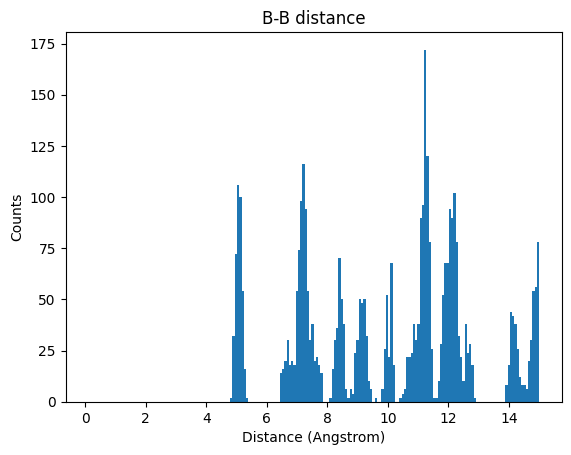

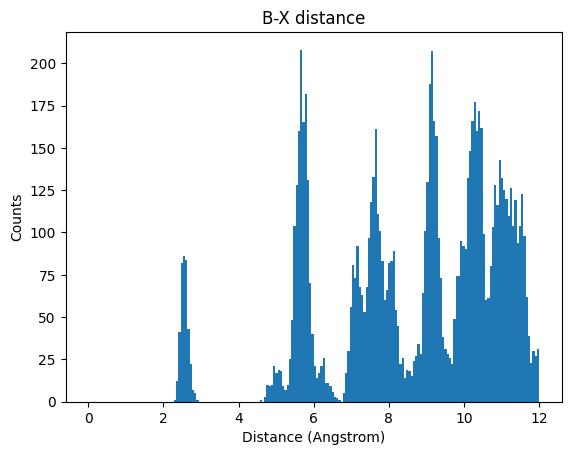

------------------------------------------------------------
Loading Trajectory files...
HzZrSe3


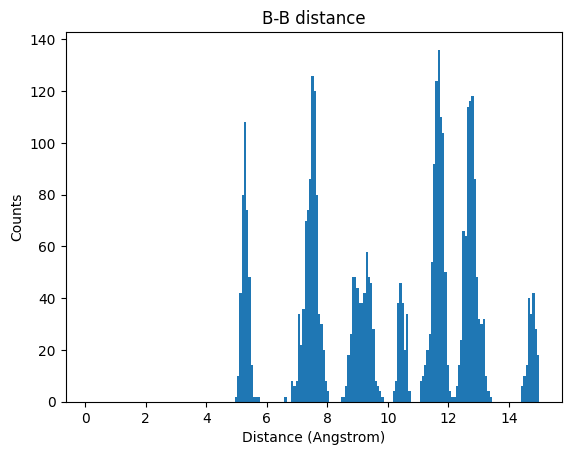

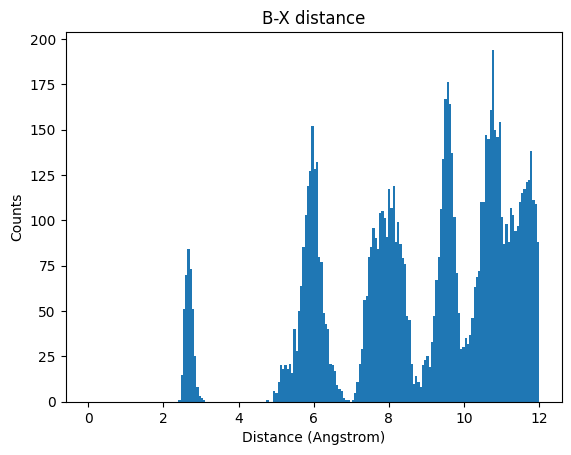

------------------------------------------------------------
Loading Trajectory files...
HzHfS3


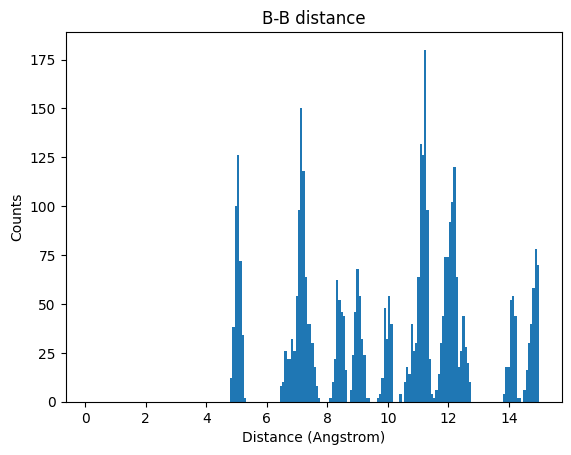

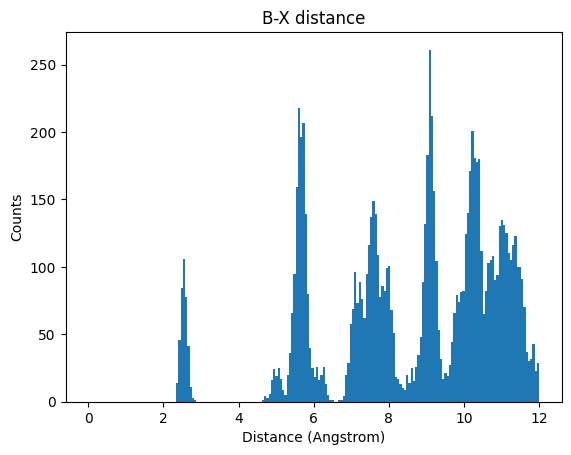

------------------------------------------------------------
Loading Trajectory files...
HzHfSe3


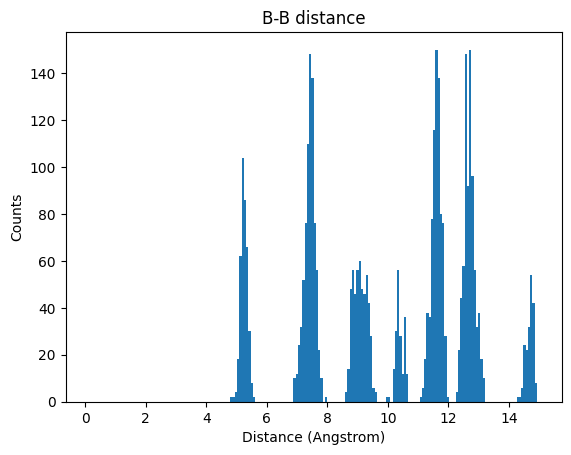

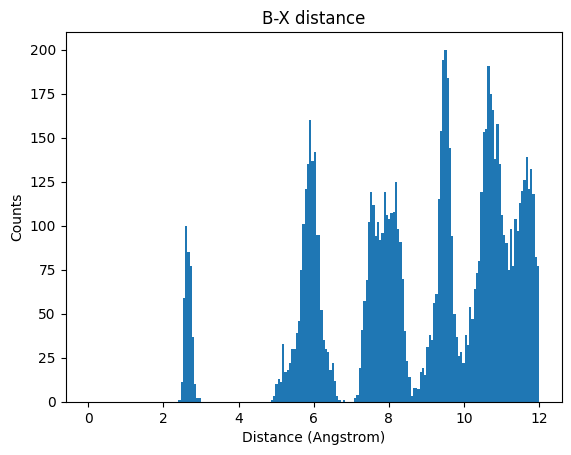

In [25]:
from pdyna import Trajectory

for system, system_info in systems.items():
    path = BASE_PATH / system / MD_PATH
    traj = Trajectory("vasp", (str(path / "POSCAR"), str(path / "XDATCAR"), str(path / "INCAR")))

    b_site = "Hf" if "Hf" in system_info["name"] else "Zr"
    x_site = "Se" if "Se" in system_info["name"] else "S"

    print(system_info["name"])
    traj.system_test(B_sites=[b_site], X_sites=[x_site]) 
    system_info |= {"trajectory": traj}

Calculating dynamics for HzZrS3...
Current sample: HzZrS3
Time Span: 0.2 ps
Frame count: 400
Reading from frame no.200
Reading every 1 frame(s)
Number of atoms: 768
Temperature: 300.0K
 


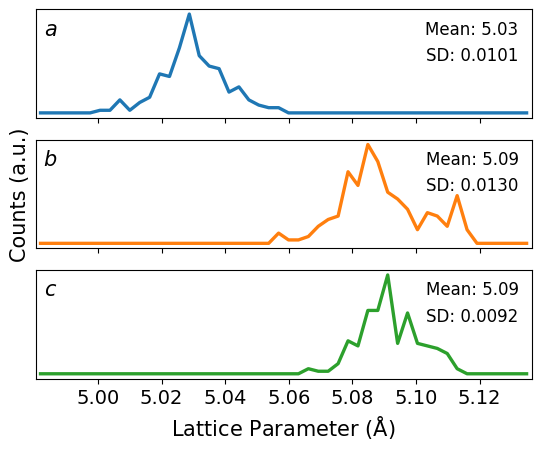

Lattice parameter:  [5.0299 5.0893 5.0918]

Computing octahedral tilting and distortion...


100%|██████████| 200/200 [00:14<00:00, 14.14it/s]


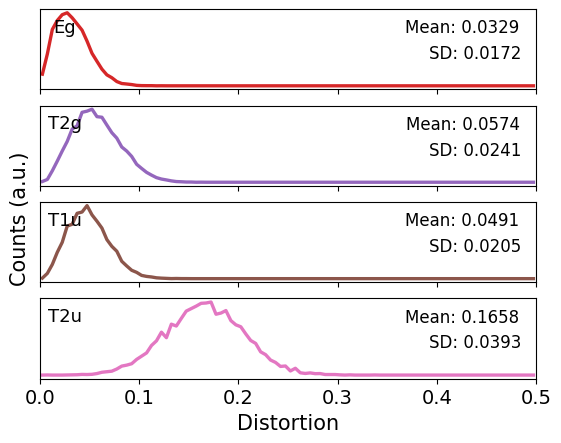

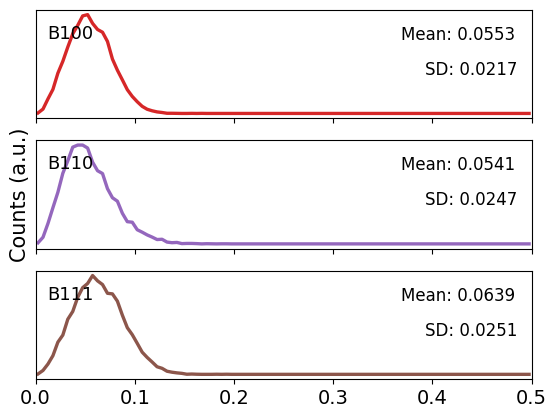

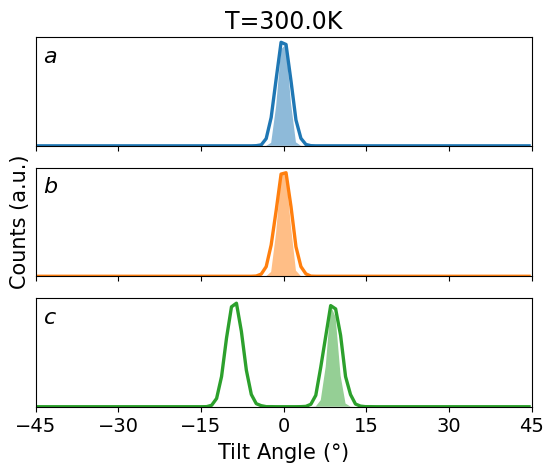

dynamic X-site distortion: [0.0329 0.0574 0.0491 0.1658]
dynamic B-site distortion: [0.0553 0.0541 0.0639]
dynamic tilting: [0.15 0.15 8.85]
tilting correlation: [0.064 0.009 1.   ]
 
 
--Elapsed Time
Data Reading:          00:00:00
Structure Resolving:   00:00:00
Lattice Parameter:     00:00:00
Tilting & Distortion:  00:00:14
Total:                 00:00:15
------------------------------------------------------------
Calculating dynamics for HzZrSe3...
Current sample: HzZrSe3
Time Span: 0.2 ps
Frame count: 400
Reading from frame no.200
Reading every 1 frame(s)
Number of atoms: 768
Temperature: 300.0K
 


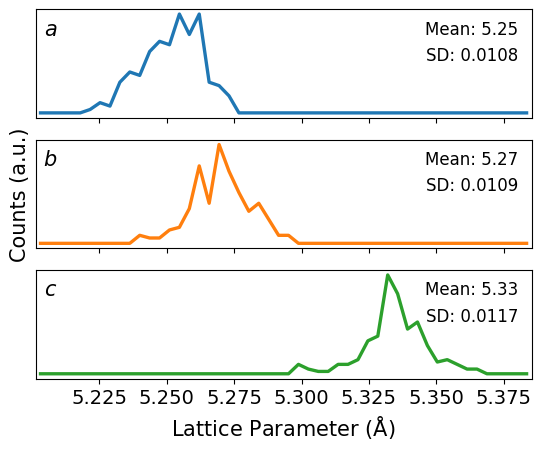

Lattice parameter:  [5.2519 5.2701 5.3346]

Computing octahedral tilting and distortion...


100%|██████████| 200/200 [00:14<00:00, 14.21it/s]


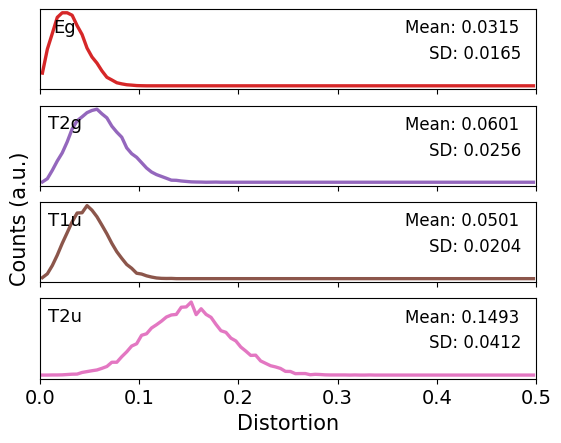

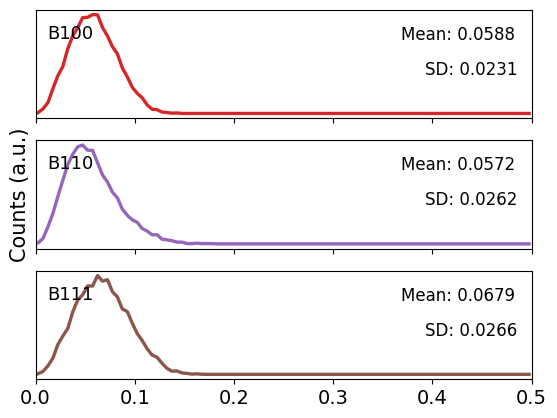

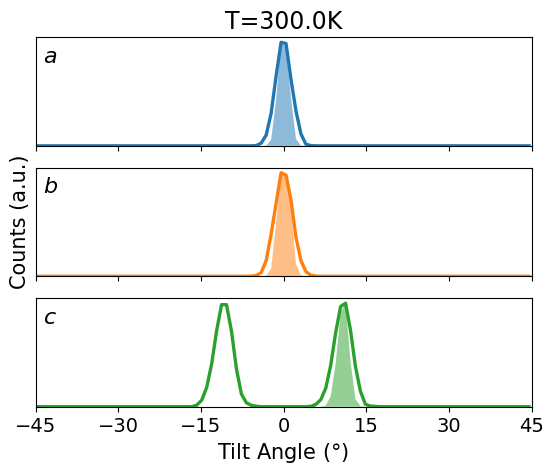

dynamic X-site distortion: [0.0315 0.0601 0.0501 0.1493]
dynamic B-site distortion: [0.0588 0.0572 0.0679]
dynamic tilting: [ 0.15  0.15 10.95]
tilting correlation: [0.002 0.076 1.   ]
 
 
--Elapsed Time
Data Reading:          00:00:00
Structure Resolving:   00:00:00
Lattice Parameter:     00:00:00
Tilting & Distortion:  00:00:14
Total:                 00:00:15
------------------------------------------------------------
Calculating dynamics for HzHfS3...
Current sample: HzHfS3
Time Span: 0.2 ps
Frame count: 400
Reading from frame no.200
Reading every 1 frame(s)
Number of atoms: 768
Temperature: 300.0K
 
!pseudo_cubic_lat: screening gets - a:165/200, b:200/200, c:200/200


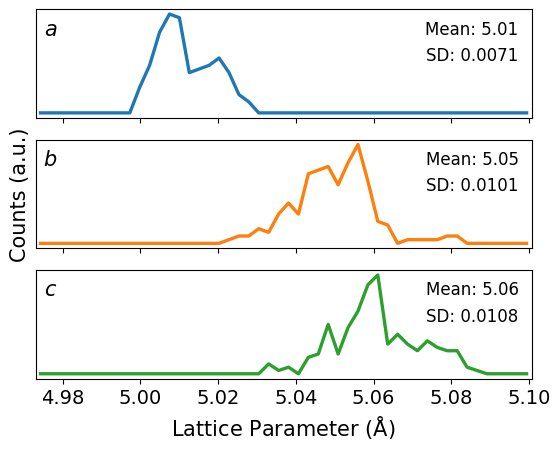

Lattice parameter:  [5.0116 5.0495 5.0609]

Computing octahedral tilting and distortion...


100%|██████████| 200/200 [00:14<00:00, 14.15it/s]


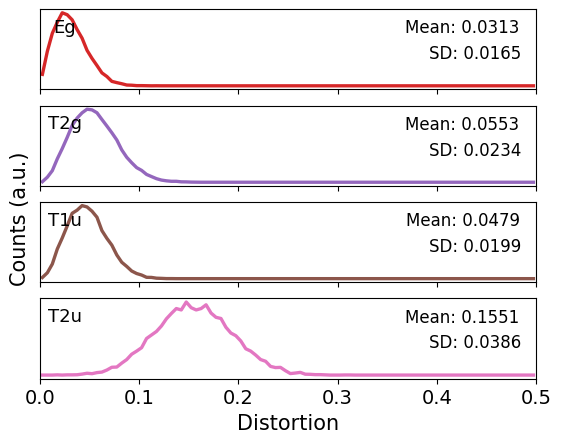

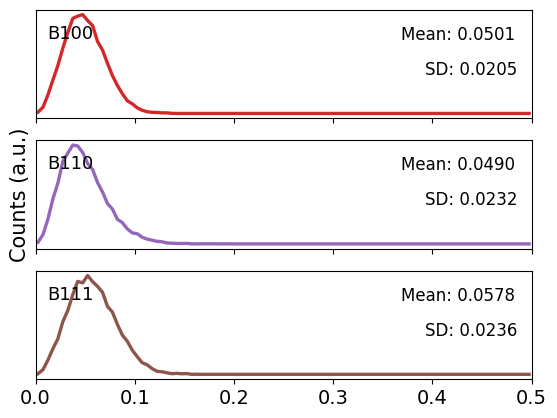

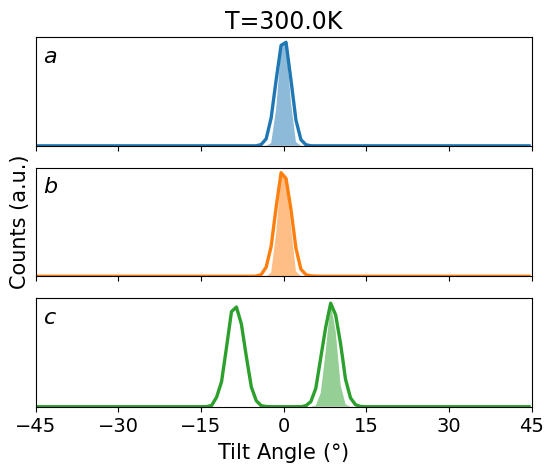

dynamic X-site distortion: [0.0313 0.0553 0.0479 0.1551]
dynamic B-site distortion: [0.0501 0.049  0.0578]
dynamic tilting: [0.15 0.15 8.85]
tilting correlation: [0.046 0.057 1.   ]
 
 
--Elapsed Time
Data Reading:          00:00:00
Structure Resolving:   00:00:00
Lattice Parameter:     00:00:00
Tilting & Distortion:  00:00:14
Total:                 00:00:15
------------------------------------------------------------
Calculating dynamics for HzHfSe3...
Current sample: HzHfSe3
Time Span: 0.2 ps
Frame count: 400
Reading from frame no.200
Reading every 1 frame(s)
Number of atoms: 768
Temperature: 300.0K
 


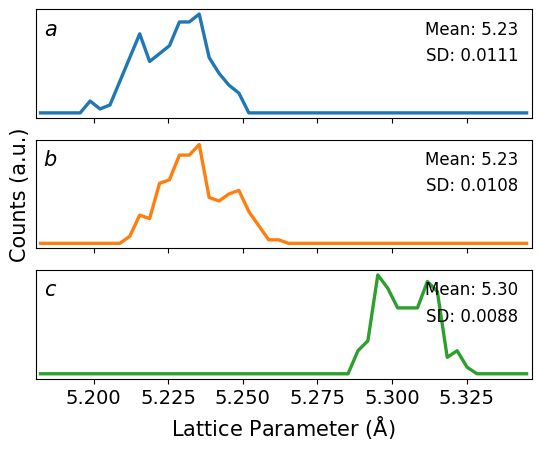

Lattice parameter:  [5.2268 5.2344 5.3049]

Computing octahedral tilting and distortion...


100%|██████████| 200/200 [00:14<00:00, 13.92it/s]


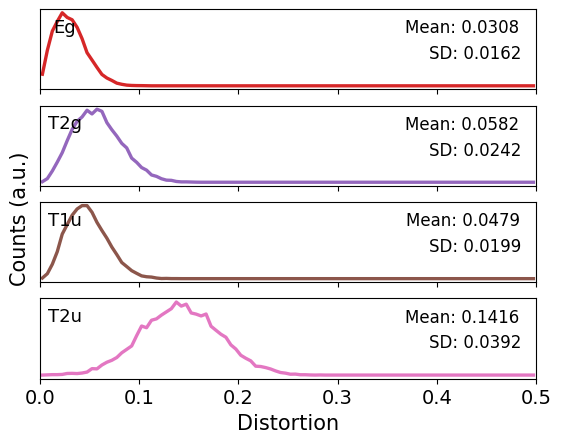

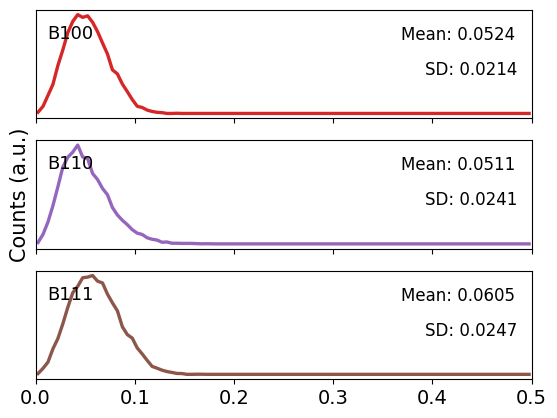

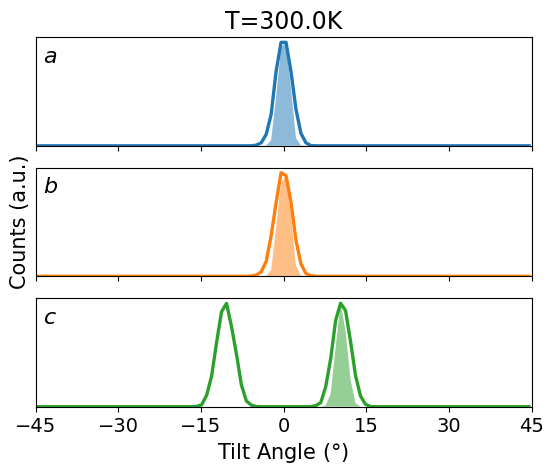

dynamic X-site distortion: [0.0308 0.0582 0.0479 0.1416]
dynamic B-site distortion: [0.0524 0.0511 0.0605]
dynamic tilting: [ 0.15  0.15 10.65]
tilting correlation: [0.077 0.154 1.   ]
 
 
--Elapsed Time
Data Reading:          00:00:00
Structure Resolving:   00:00:00
Lattice Parameter:     00:00:00
Tilting & Distortion:  00:00:14
Total:                 00:00:15
------------------------------------------------------------


In [26]:
import numpy as np
from pdyna.structural import periodicity_fold

# based on the above plots we can define the system cutoffs

systems["01_hzzrs3"]["cutoffs"] = {
    'B-sites': ['Zr'],
    'X-sites': ['S'],
    'fpg_val_BB': [[4, 8], [5, 7.5]],      # [lower/upper bound that covers only NN1 and NN2], [NN1/NN2 distance]
    'fpg_val_BX': [[2, 6.5], [2.3, 5.9]],  # [lower/upper bound that covers only NN1 and NN2, NN1/NN2 distance]
} 

systems["02_hzzrse3"]["cutoffs"] = {
    'B-sites': ['Zr'],
    'X-sites': ['Se'],
    'fpg_val_BB': [[4, 8.5], [5.2, 7.9]],      # [lower/upper bound that covers only NN1 and NN2], [NN1/NN2 distance]
    'fpg_val_BX': [[2, 7], [2.5, 5.9]],  # [lower/upper bound that covers only NN1 and NN2, NN1/NN2 distance]
}

systems["03_hzhfs3"]["cutoffs"] = {
    'B-sites': ['Hf'],
    'X-sites': ['S'],
    'fpg_val_BB': [[4, 8], [5, 7.5]],      # [lower/upper bound that covers only NN1 and NN2], [NN1/NN2 distance]
    'fpg_val_BX': [[2, 6.5], [2.3, 5.9]],  # [lower/upper bound that covers only NN1 and NN2, NN1/NN2 distance]
}

systems["04_hzhfse3"]["cutoffs"] = {
    'B-sites': ['Hf'],
    'X-sites': ['Se'],
    'fpg_val_BB': [[4, 8.5], [5.5, 7.8]],      # [lower/upper bound that covers only NN1 and NN2], [NN1/NN2 distance]
    'fpg_val_BX': [[2, 7], [2.8, 6]],  # [lower/upper bound that covers only NN1 and NN2, NN1/NN2 distance]
}

def get_tilt_histogram_data(traj, n_bins=100, tilt_range=(-45, 45)):
    """
    Returns a dictionary structure containing histogram data for a, b, and c axes.
    """
    raw_tilt = traj.Tilting
    folded_tilt = periodicity_fold(raw_tilt, n_fold=4) 
    raw_corr = traj.Tilting_Corr
    axes_map = {0: 'a', 1: 'b', 2: 'c'}
    result = {}
    
    for i in range(3):
        axis_label = axes_map[i]
        flat_tilt = folded_tilt[:, :, i].reshape(-1)
        y_tilt, bin_edges = np.histogram(flat_tilt, bins=n_bins, range=tilt_range)
        bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
        
        yt = y_tilt / np.max(y_tilt) if np.max(y_tilt) > 0 else y_tilt
        
        if raw_corr.shape[2] == 6:
            flat_corr = np.concatenate((raw_corr[:, :, 2*i], raw_corr[:, :, 2*i+1]), axis=0).reshape(-1)
        else:
            flat_corr = raw_corr[:, :, i].reshape(-1)
            
        y_corr, _ = np.histogram(flat_corr, bins=n_bins, range=tilt_range)
        yc = y_corr / np.max(y_corr) if np.max(y_corr) > 0 else y_corr
        yy_shaded = yt * yc
        result[axis_label] = {
            "angle": bin_centers.tolist(),
            "tilt_intensity": yt.tolist(),
            "corr_intensity": yc.tolist(),
            "shaded_intensity": yy_shaded.tolist()
        }
            
    return result

all_records = []
final_output = {}
for system, system_info in systems.items():
    print(f"Calculating dynamics for {system_info['name']}...")
    system_info["trajectory"].dynamics(
        uniname=system_info["name"],          # A unique user-defined name for this trajectory, will be used in printing and figure saving
        read_mode=1,               # key parameter, 1: equilibration mode, 2: quench/anneal mode
        toggle_lat=True,           # switch of lattice parameter calculation
        toggle_tilt_distort=True,  # switch of octahedral tilting and distortion calculation
        toggle_MO=True,            # switch of molecular orientation (MO) calculation (for organic A-site)
        lat_method=1,              # enable pseudo-cubic lattice parameter
        system_overwrite=system_info["cutoffs"],
    )
    final_output[system_info["name"]] = get_tilt_histogram_data(system_info["trajectory"])

with open("../data/tilt_data.json", "w") as f:
    json.dump(final_output, f, indent=4)

Plotting HzZrS3...
Plotting HzZrSe3...
Plotting HzHfS3...
Plotting HzHfSe3...


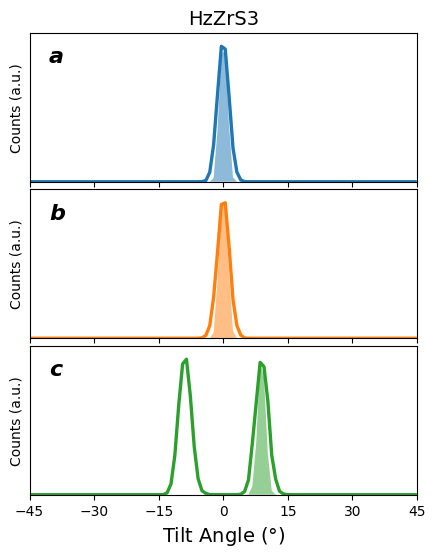

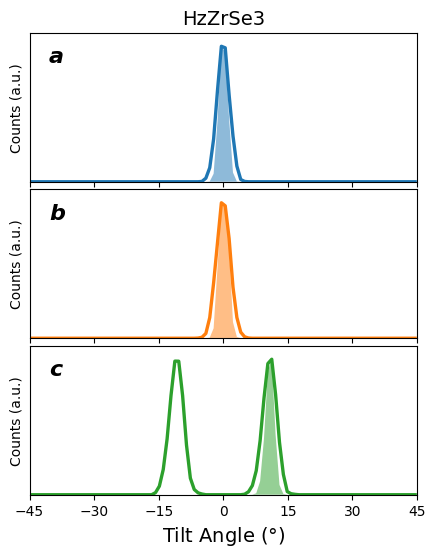

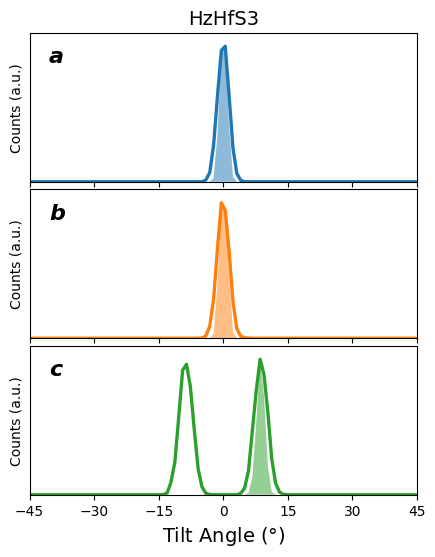

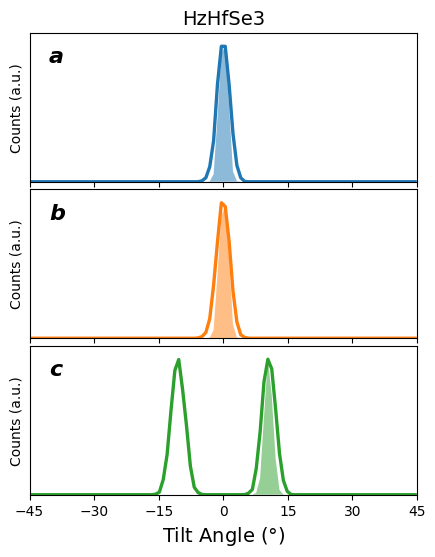

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Load data
df = pd.read_json("tilt_data.json")
materials = df["Material"].unique()

colors = {'a': 'C0', 'b': 'C1', 'c': 'C2'} # Blue, Orange, Green
fill_alpha = 0.5

for material in materials:
    fig, axes = plt.subplots(3, 1, figsize=(5, 6), sharex=True, sharey=True)
    mat_data = df[df["Material"] == material]
    
    print(f"Plotting {material}...")
    
    for i, axis in enumerate(['a', 'b', 'c']):
        ax = axes[i]
        data = mat_data[mat_data["Axis"] == axis]
        
        ax.plot(data["Angle"], data["Tilt_Intensity"], 
                color=colors[axis], linewidth=2.4, label=axis)
        
        ax.fill_between(data["Angle"], data["Shaded_Intensity"], 0, 
                        facecolor=colors[axis], alpha=fill_alpha, interpolate=True)
        
        ax.text(0.05, 0.8, axis, transform=ax.transAxes, 
                fontsize=16, fontweight='bold', style='italic')
        
        ax.set_ylim(0, 1.1)
        ax.set_yticks([])
        ax.set_ylabel("Counts (a.u.)")

    axes[-1].set_xlabel(r'Tilt Angle ($\degree$)', fontsize=14)
    axes[-1].set_xlim(-45, 45)
    axes[-1].set_xticks([-45, -30, -15, 0, 15, 30, 45])
    
    plt.subplots_adjust(hspace=0.05)
    axes[0].set_title(f"{material}", fontsize=14)
    
    for ax in axes[:-1]:
        ax.tick_params(labelbottom=False)
        ax.set_xlabel("")

    # plt.savefig(f"plot_{material}_tilt_corr.png", dpi=300, bbox_inches='tight')
    # plt.show()